# Day 4 — t-SNE & Anomaly Detection

## Breast Cancer Wisconsin Dataset

This notebook explores t-SNE for visualizing high-dimensional data and Isolation Forest for unsupervised anomaly detection.

The Breast Cancer Wisconsin dataset is used because it contains 30 numerical features, making it suitable for studying dimensionality reduction and high-dimensional visualization.

The notebook also connects the concepts learned in Day 3, particularly PCA, with the local-structure visualization provided by t-SNE.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")


print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [2]:
print("Feature names:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

Feature names:
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


In [3]:
print(data.target_names)

['malignant' 'benign']


In [4]:
target_mapping = {
    0: "malignant",
    1: "benign"
}

y_labels = y.map(target_mapping)

print(y_labels.value_counts())

target
benign       357
malignant    212
Name: count, dtype: int64


In [5]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [6]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [10]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_pca = pca_pipeline.fit_transform(X)

print("Original shape:", X.shape)
print("PCA shape:", X_pca.shape)

Original shape: (569, 30)
PCA shape: (569, 2)


In [11]:
pca = pca_pipeline.named_steps["pca"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.44272026 0.18971182]

Total explained variance:
0.6324320765155944


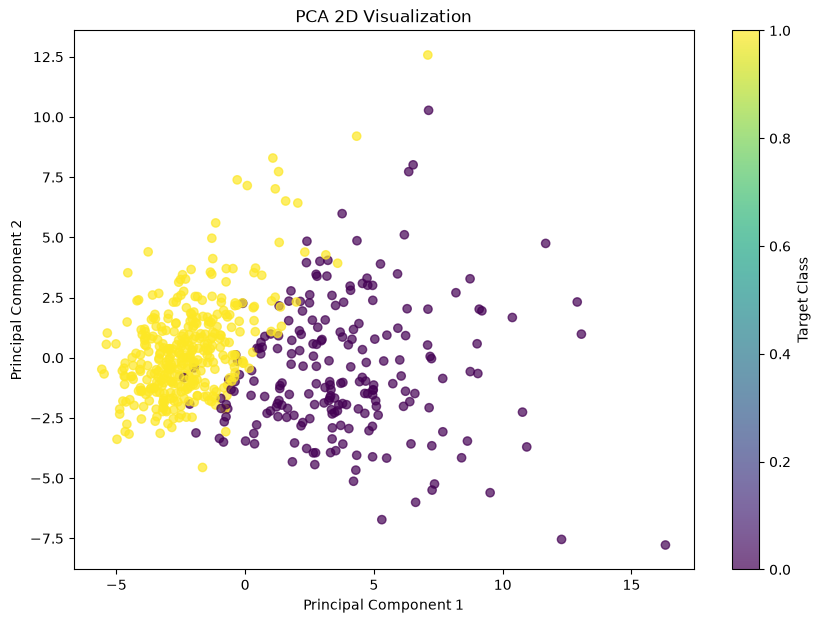

In [12]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")

plt.colorbar(scatter, label="Target Class")

plt.show()

In [13]:
pca_full_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

X_pca_full = pca_full_pipeline.fit_transform(X)

explained_variance = (
    pca_full_pipeline
    .named_steps["pca"]
    .explained_variance_ratio_
)

cumulative_variance = explained_variance.cumsum()

print("Variance explained by first 5 components:")
print(explained_variance[:5])

print("\nCumulative variance by first 5 components:")
print(cumulative_variance[:5])

Variance explained by first 5 components:
[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768]

Cumulative variance by first 5 components:
[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274]


### PCA Interpretation

The first principal component 
explains 44.27% of the total variance, while the second explains 18.97%. Together, the first two components explain 63.24% of the total variance.

When considering the first five components, the cumulative explained variance reaches 84.73%. This shows that the first two components provide a useful two-dimensional representation for visualization, but they do not capture all of the variability present in the original 30-dimensional dataset.

For this reason, PCA will be used as a global-structure visualization baseline, while t-SNE will later be used to investigate local neighborhood structure.

In [14]:
from sklearn.manifold import TSNE


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("t-SNE shape:", X_tsne.shape)

Original shape: (569, 30)
t-SNE shape: (569, 2)


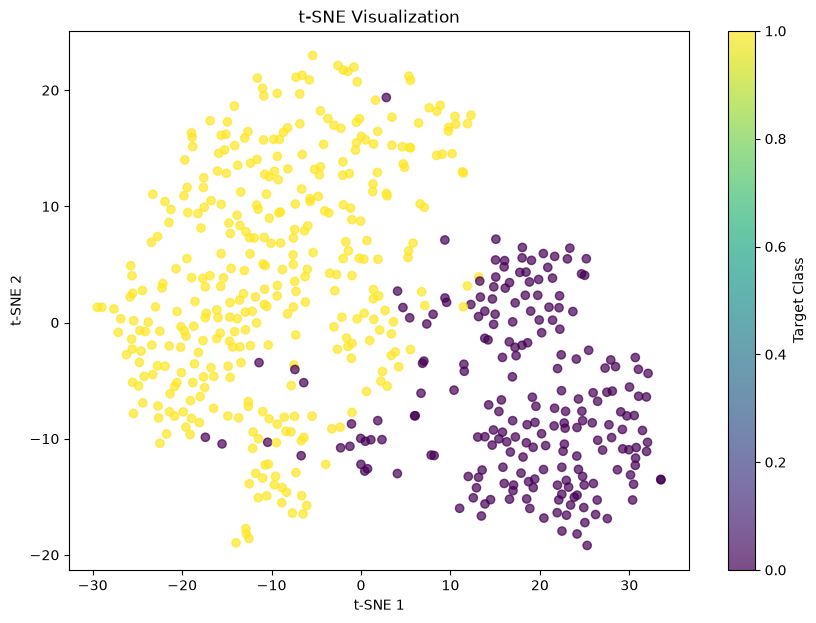

In [15]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")

plt.colorbar(scatter, label="Target Class")

plt.show()

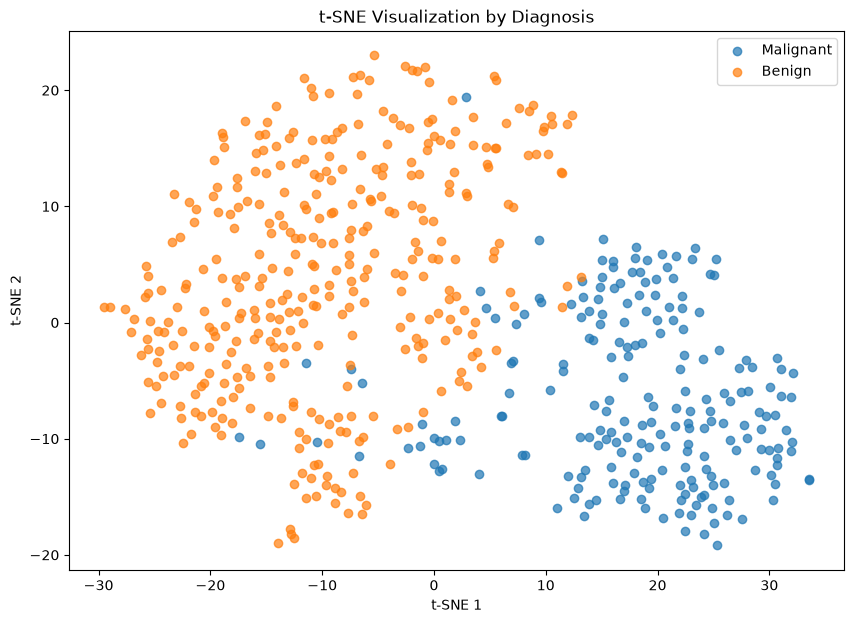

In [16]:
plt.figure(figsize=(10, 7))

for class_value, class_name in zip([0, 1], ["Malignant", "Benign"]):
    mask = y == class_value
    
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization by Diagnosis")
plt.legend()
plt.show()

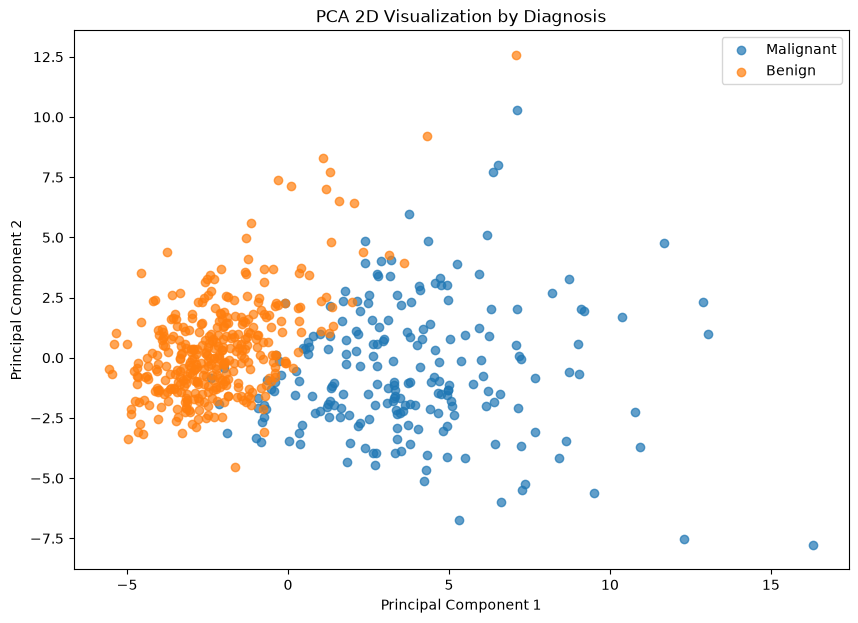

In [17]:
plt.figure(figsize=(10, 7))

for class_value, class_name in zip([0, 1], ["Malignant", "Benign"]):
    mask = y == class_value
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization by Diagnosis")
plt.legend()
plt.show()